<a href="https://colab.research.google.com/github/TanishqKadyan18/data-cleaning-visualization/blob/main/Predictive_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate 100 rows of synthetic student performance data
study_hours = np.random.randint(1, 15, 100)        # hours studied per week
attendance = np.random.randint(40, 100, 100)       # attendance percentage
assignments = np.random.randint(1, 10, 100)        # assignments completed

# Rule for pass/fail (target variable)
# Students with good study hours, attendance, and assignments are more likely to pass
pass_fail = [
    1 if (h > 6 and a > 70 and asg > 5) else 0
    for h, a, asg in zip(study_hours, attendance, assignments)
]

# Create DataFrame
df = pd.DataFrame({
    "StudyHours": study_hours,
    "Attendance": attendance,
    "Assignments": assignments,
    "Pass": pass_fail
})

# Save as CSV
df.to_csv("student_performance.csv", index=False)

print("CSV file with 100 rows created successfully!")
df.head()

CSV file with 100 rows created successfully!


,StudyHours,Attendance,Assignments,Pass
0,7,62,3,0
1,4,99,6,0
2,13,96,2,0
3,11,79,9,1
4,8,60,5,0


In [2]:
df = pd.read_csv("student_performance.csv")
print(df.shape)   # should show (100, 4)
print(df.head())

(100, 4)
   StudyHours  Attendance  Assignments  Pass
0           7          62            3     0
1           4          99            6     0
2          13          96            2     0
3          11          79            9     1
4           8          60            5     0


In [3]:
import pandas as pd

# Load the CSV you created earlier
df = pd.read_csv("student_performance.csv")

# Quick look at the data
print(df.shape)
df.head()

(100, 4)


,StudyHours,Attendance,Assignments,Pass
0,7,62,3,0
1,4,99,6,0
2,13,96,2,0
3,11,79,9,1
4,8,60,5,0


In [5]:
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = df.drop("Pass", axis=1)
y = df["Pass"]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [7]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
from sklearn.metrics import accuracy_score

# Predictions
y_pred_lr = lr.predict(X_test).round()   # round regression output
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("Linear Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Linear Regression Accuracy: 1.0
Decision Tree Accuracy: 0.95
Random Forest Accuracy: 1.0


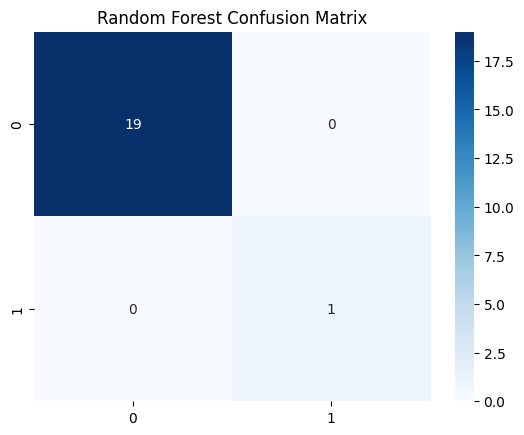

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

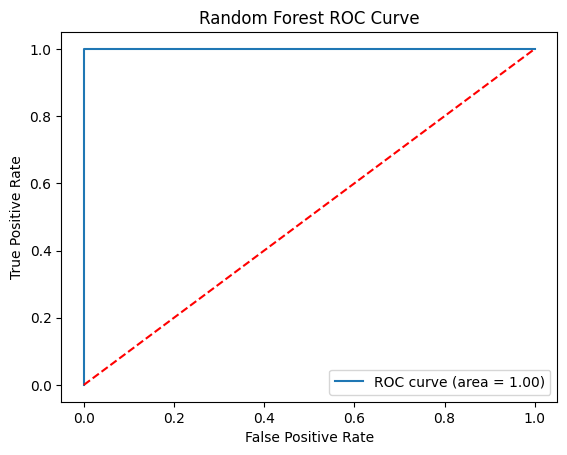

In [11]:
from sklearn.metrics import roc_curve, auc

y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'r--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

Aim: Build predictive models using ML algorithms.

Objective: Train, test, and evaluate models for accuracy.

Outcome: Hands-onon experience in supervised learning, model comparison, and performance visualisation